In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!mkdir -p /content/two_dataset_combined

!unzip -q \
"/content/drive/MyDrive/baselines_original/two_dataset_combined.zip" \
-d "/content/two_dataset_combined"

In [4]:
import time
import os
import numpy as np
import torch

import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim #for gradient descent

# alexnet
import torchvision.models

from torch.utils.data import DataLoader

from sklearn.metrics import roc_auc_score, average_precision_score

In [5]:
from datetime import datetime
import pytz

# Set timezone to specific region

tz = pytz.timezone("Asia/Singapore")

local_time = datetime.now(tz)

# 0. Data Loading

In [6]:
data_dir = '/content/two_dataset_combined/images/'
train_dir = os.path.join(data_dir, 'train/')
val_dir = os.path.join(data_dir, 'validation/')
test_dir = os.path.join(data_dir, 'test/')

# classes are folders in each directory with these names
classes = ['real', 'ai']

In [7]:
from PIL import Image
from torch.utils.data import Dataset

class PairDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.samples = []

        # Label convention
        # real = 0
        # AI   = 1

        pair_folders = sorted(os.listdir(root_dir))


        for pair_name in pair_folders:
            pair_path = os.path.join(root_dir, pair_name)

            # Ignore anything that is not a folder
            if not os.path.isdir(pair_path):
                continue

            real_path = os.path.join(pair_path, "real.jpg")

            if os.path.exists(real_path):
                self.samples.append((real_path, 0))

            ai_path = os.path.join(pair_path, "ai.jpg")

            if os.path.exists(ai_path):
                self.samples.append((ai_path, 1))


    def __len__(self):
        return len(self.samples)


    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [8]:
def print_size_transformed_data(data, type_of_data="Training"):
    print(type_of_data, " images:", len(data))
    image, label = data[5]

    print(image.shape)
    print(label)

In [9]:
def load_data(train_data, val_data, test_data, batch_size, num_workers, pin_memory=True,):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4,pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=4,pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4,pin_memory=True, persistent_workers=True)

    images, labels = next(iter(train_loader))
    print(images.shape)
    print(labels.shape)

    return train_loader, val_loader, test_loader

In [29]:
def load_data_w_visual(train_data, val_data, test_data, batch_size, num_workers, pin_memory=True,):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4,pin_memory=True, persistent_workers=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=4,pin_memory=True, persistent_workers=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=4,pin_memory=True, persistent_workers=True)

    #Visualize some sample data

    # obtain one batch of training images
    dataiter = iter(train_loader)

    images, labels = next(dataiter)
    images = images.numpy() # convert images to numpy for display

    # Denormalize images for plotting
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    # Reshape mean and std for broadcasting: (channels, 1, 1)
    images = images * std[:, None, None] + mean[:, None, None]
    images = np.clip(images, 0, 1) # Clip values to [0, 1] range after denormalization

    # plot the images in the batch, along with the corresponding labels
    fig = plt.figure(figsize=(50, 16)) # Adjusted figure height for 4 rows
    for idx in np.arange(min(len(images), 30)): # Limit plotting to 20 images (4x5)
        ax = fig.add_subplot(3,10, idx+1, xticks=[], yticks=[]) # Changed to 4 rows, 5 columns
        plt.imshow(np.transpose(images[idx], (1, 2, 0))) # Adjusted for correct display order
        ax.set_title(classes[labels[idx]])
    plt.show()

    return train_loader, val_loader, test_loader

In [11]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print("GPU:", torch.cuda.get_device_name(0))

cuda
GPU: NVIDIA A100-SXM4-40GB


In [12]:
def plot_history(history, auc=True, ap=True, model_name="ResNet Baseline"):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"],label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(model_name + " Training vs Validation Loss")
    plt.legend()
    plt.grid()

    plt.show()


    plt.figure(figsize=(8, 5))
    plt.plot(epochs, [x * 100 for x in history["train_acc"]], label="Training Accuracy")
    plt.plot(epochs, [x * 100 for x in history["val_acc"]], label="Validation Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(model_name + " Training vs Validation Accuracy")
    plt.legend()
    plt.grid()

    plt.show()

    if auc:
        plt.figure(figsize=(8, 5))
        plt.plot(epochs, history["train_auc"], label="Training AUROC")
        plt.plot(epochs, history["val_auc"], label="Validation AUROC")

        plt.xlabel("Epoch")
        plt.ylabel("AUROC")
        plt.title(model_name+ " Training vs Validation AUROC")
        plt.ylim(0.5, 1.0)
        plt.legend()
        plt.grid()

        plt.show()

    if ap:
        plt.figure(figsize=(16, 10))
        plt.plot(epochs, history["train_ap"],label="Training AP")
        plt.plot(epochs, history["val_ap"], label="Validation AP")

        plt.xlabel("Epoch")
        plt.ylabel("Average Precision")
        plt.title(model_name + " Training vs Validation AP")
        plt.ylim(0.0, 1.0)
        plt.legend()
        plt.grid()

        plt.show()

# 1. ResNet Baseline



## 1.1 Preprocessing

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

local_time = datetime.now(tz)
print("Job starting on Singapore time:", local_time)
train_data = PairDataset(root_dir=train_dir, transform=train_transform)


local_time = datetime.now(tz)
print("Job ending on Singapore time:", local_time)


Job starting on Singapore time: 2026-08-31 20:43:11.179513+08:00
Job ending on Singapore time: 2026-08-31 20:43:11.340896+08:00


In [14]:
print_size_transformed_data(train_data)

Training  images: 15302
torch.Size([3, 224, 224])
1


In [15]:
local_time = datetime.now(tz)
print("Job starting on Singapore time:", local_time)

val_data = PairDataset(root_dir=val_dir, transform=val_test_transform)
test_data = PairDataset(root_dir=test_dir, transform=val_test_transform)

local_time = datetime.now(tz)
print("Job ending on Singapore time:", local_time)

Job starting on Singapore time: 2026-08-31 20:43:18.052595+08:00
Job ending on Singapore time: 2026-08-31 20:43:18.093469+08:00


In [16]:
print_size_transformed_data(val_data, "Validation")
print_size_transformed_data(test_data, "Test")

Validation  images: 1914
torch.Size([3, 224, 224])
1
Test  images: 1912
torch.Size([3, 224, 224])
1


In [30]:
train_loader, val_loader, test_loader = load_data_w_visual(train_data, val_data, test_data, 32, 4)

Output hidden; open in https://colab.research.google.com to view.

In [20]:
import time

start = time.time()

for i, (images, labels) in enumerate(train_loader):
    if i == 100:
        break

elapsed = time.time() - start

print(f"100 batches: {elapsed:.2f} sec")
print(f"Per batch: {elapsed/100:.2f} sec")

100 batches: 1.79 sec
Per batch: 0.02 sec


In [21]:
print(train_data.root_dir)

/content/two_dataset_combined/images/train/


## 1.2 ResNet Baseline Setup

In [22]:
import torch
import torch.nn as nn

from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import roc_auc_score

In [23]:
import torch
import torch.nn as nn

from torchvision.models import resnet18, ResNet18_Weights


class ResNetBaseline(nn.Module):

    def __init__(self, dropout=0.3):

        super().__init__()

        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        feature_dim = backbone.fc.in_features

        backbone.fc = nn.Identity()
        self.backbone = backbone

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feature_dim, 1)
        )


    def forward(self, images):

        features = self.backbone(images)
        logits = self.classifier(features)

        return logits

In [24]:
def train_model(model, train_loader, val_loader, device, epochs=10, learning_rate=1e-4, threshold=0.5):

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_auc": [],
        "val_loss": [],
        "val_acc": [],
        "val_auc": [],
    }

    model = model.to(device)

    for epoch in range(epochs):

        local_time = datetime.now(tz)

        print(
            f"\nEpoch {epoch+1}/{epochs} START: "
            f"{local_time.strftime('%Y-%m-%d %H:%M:%S')}"
        )


        model.train()

        train_loss = torch.tensor(0.0, device=device)
        train_correct = torch.tensor(0, device=device)

        train_total = 0

        train_probs = []
        train_labels = []

        for images, labels in train_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.float().to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += (loss.detach() * images.size(0))
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= threshold).float()

            train_correct += (predictions == labels).sum()
            train_total += labels.size(0)

            # Keep everything on GPU
            train_probs.append(probabilities.detach())
            train_labels.append(labels.detach())


        train_loss = train_loss.item() / train_total
        train_acc = train_correct.item() / train_total
        train_probs = torch.cat(train_probs).cpu().numpy()
        train_labels = torch.cat(train_labels).cpu().numpy()
        train_auc = roc_auc_score(train_labels, train_probs)



        model.eval()

        val_loss = torch.tensor(0.0, device=device)

        val_correct = torch.tensor(0, device=device)

        val_total = 0

        val_probs = []
        val_labels = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device, non_blocking=True)

                labels = labels.float().to(device, non_blocking=True)

                logits = model(images).squeeze(1)

                loss = criterion(logits, labels)

                val_loss += (loss.detach() * images.size(0))

                probabilities = torch.sigmoid(logits)

                predictions = (probabilities >= threshold).float()

                val_correct += (predictions == labels).sum()

                val_total += labels.size(0)

                val_probs.append(probabilities.detach())

                val_labels.append(labels.detach())

        val_loss = val_loss.item() / val_total
        val_acc = val_correct.item() / val_total
        val_probs = torch.cat(val_probs).cpu().numpy()
        val_labels = torch.cat(val_labels).cpu().numpy()
        val_auc = roc_auc_score(val_labels, val_probs)

        # =================================
        # HISTORY
        # =================================

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_auc"].append(train_auc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.4f} "
            f"| Train AUC: {train_auc:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val Acc: {val_acc:.4f} "
            f"| Val AUC: {val_auc:.4f}"
        )

        local_time = datetime.now(tz)

        print(
            f"Epoch {epoch+1}/{epochs} END: "
            f"{local_time.strftime('%Y-%m-%d %H:%M:%S')}"
        )

    return model, history

In [31]:
local_time = datetime.now(tz)
print("Job starting on Singapore time:", local_time)

model = ResNetBaseline(dropout=0.3)

EPOCHS = 10
LEARNING_RATE = 1e-4

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE
)

local_time = datetime.now(tz)
print("Job ending on Singapore time:", local_time)

Job starting on Singapore time: 2026-08-31 20:52:24.434058+08:00

Epoch 1/10 START: 2026-08-31 20:52:24
Epoch [1/10] | Train Loss: 0.3642 | Train Acc: 0.8341 | Train AUC: 0.9182 | Val Loss: 0.3151 | Val Acc: 0.8636 | Val AUC: 0.9464
Epoch 1/10 END: 2026-08-31 20:52:35

Epoch 2/10 START: 2026-08-31 20:52:35
Epoch [2/10] | Train Loss: 0.1871 | Train Acc: 0.9243 | Train AUC: 0.9785 | Val Loss: 0.3643 | Val Acc: 0.8610 | Val AUC: 0.9425
Epoch 2/10 END: 2026-08-31 20:52:45

Epoch 3/10 START: 2026-08-31 20:52:45
Epoch [3/10] | Train Loss: 0.1252 | Train Acc: 0.9539 | Train AUC: 0.9901 | Val Loss: 0.4350 | Val Acc: 0.8422 | Val AUC: 0.9437
Epoch 3/10 END: 2026-08-31 20:52:56

Epoch 4/10 START: 2026-08-31 20:52:56
Epoch [4/10] | Train Loss: 0.0921 | Train Acc: 0.9656 | Train AUC: 0.9946 | Val Loss: 0.3437 | Val Acc: 0.8767 | Val AUC: 0.9549
Epoch 4/10 END: 2026-08-31 20:53:06

Epoch 5/10 START: 2026-08-31 20:53:06
Epoch [5/10] | Train Loss: 0.0664 | Train Acc: 0.9754 | Train AUC: 0.9972 | Val 

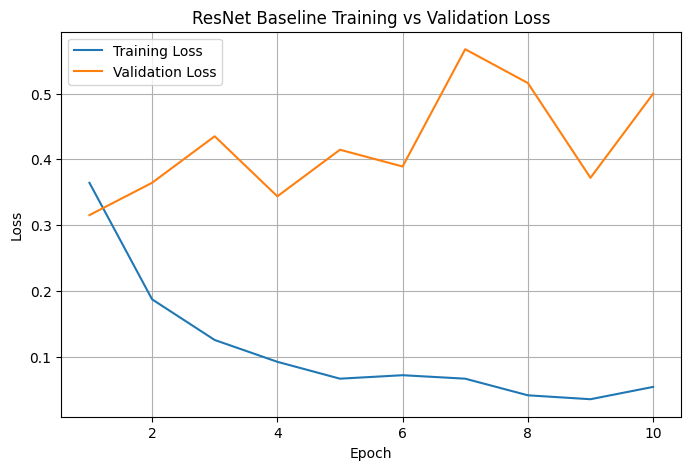

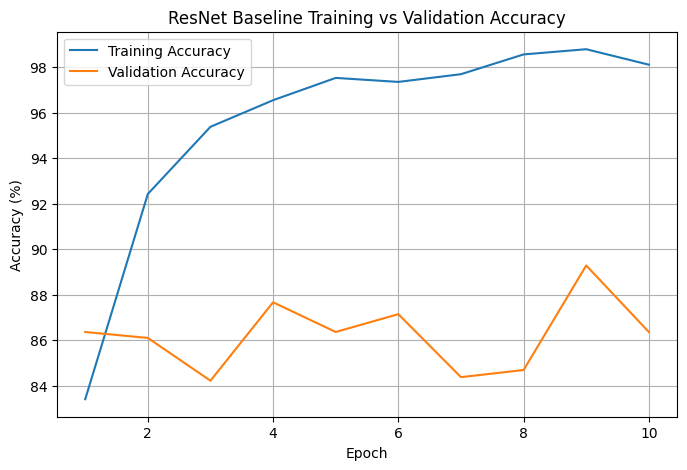

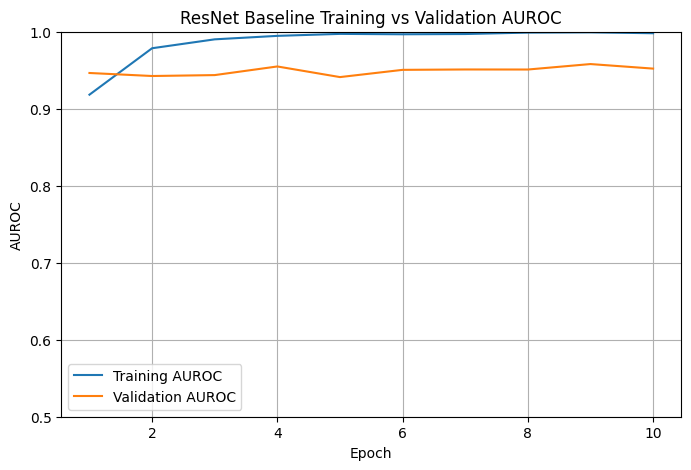

In [32]:
plot_history(history, ap=False, model_name="ResNet Baseline")

In [33]:
def evaluate_model(model, test_loader, device):

    criterion = nn.BCEWithLogitsLoss()

    # Evaluation mode
    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0

    test_probs = []
    test_labels = []


    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = (labels.float().to(device))

            logits = model(images).squeeze(1)
            loss = criterion(logits, labels)
            test_loss += (loss.item() * images.size(0))

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            test_correct += (predictions == labels).sum().item()
            test_total += (labels.size(0))

            test_probs.extend(probabilities.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())

    test_loss = (test_loss / test_total)
    test_acc = (test_correct / test_total)
    test_auc = roc_auc_score(test_labels, test_probs)
    test_ap = average_precision_score(test_labels, test_probs)

    test_predictions = [1 if p >= 0.5 else 0 for p in test_probs]

    real_correct = 0
    real_total = 0

    ai_correct = 0
    ai_total = 0


    for label, prediction in zip(test_labels, test_predictions):

        if label == 0:
            real_total += 1
            if prediction == 0:
                real_correct += 1

        elif label == 1:
            ai_total += 1
            if prediction == 1:
                ai_correct += 1


    real_acc = real_correct / real_total if real_total > 0 else 0
    ai_acc = ai_correct / ai_total if ai_total > 0 else 0

    print("======== Test Results ========")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc*100:.2f}%")
    print(f"Test AUROC: {test_auc:.4f}")
    print(f"Test AP: {test_ap:.4f}")
    print(f"Real Accuracy: {real_acc*100:.2f}%")
    print(f"AI Accuracy: {ai_acc*100:.2f}%")


    return {
        "loss": test_loss,
        "accuracy": test_acc,
        "auroc": test_auc,
        "ap": test_ap,
        "real_accuracy": real_acc,
        "ai_accuracy": ai_acc
    }

In [34]:
test_results = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device
)

======== Test Results ========
Test Loss: 0.4547
Test Accuracy: 87.34%
Test AUROC: 0.9561
Test AP: 0.9555
Real Accuracy: 81.07%
AI Accuracy: 93.62%


In [35]:
def print_test_result(test_results):
    print("======== Test Results ========")
    print(f"Test Loss: {test_results["loss"]:.4f}")
    print(f"Test Accuracy: {test_results["accuracy"]*100:.2f}%")
    print(f"Test AUROC: {test_results["auroc"]:.4f}")
    print(f"Test AP: {test_results["ap"]:.4f}")
    print(f"Real Accuracy: {test_results["real_accuracy"]*100:.2f}%")
    print(f"AI Accuracy: {test_results["ai_accuracy"]*100:.2f}%")


In [ ]:
print_test_result(test_results)

======== Test Results ========
Test Loss: 0.3443
Test Accuracy: 90.08%
Test AUROC: 0.9675
Test AP: 0.9658
Real Accuracy: 86.27%
AI Accuracy: 93.89%


In [ ]:
best_epoch = 10

# 2. Clip Baseline

## 2.1 Data Loading

In [36]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00


In [38]:
import open_clip

In [39]:
clip_backbone, clip_train_transform, clip_val_transform = (
    open_clip.create_model_and_transforms(
        'ViT-B-32',
        pretrained='laion2b_s34b_b79k'
    )
)

clip_train_data = PairDataset(root_dir=train_dir, transform=clip_val_transform)


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

In [40]:
print_size_transformed_data(train_data)

Training  images: 15302
torch.Size([3, 224, 224])
1


In [41]:
clip_val_data = PairDataset(root_dir=val_dir, transform=clip_val_transform)
clip_test_data = PairDataset(root_dir=val_dir, transform=clip_val_transform)

In [42]:
print_size_transformed_data(val_data, "Validation")
print_size_transformed_data(test_data, "Test")

Validation  images: 1914
torch.Size([3, 224, 224])
1
Test  images: 1912
torch.Size([3, 224, 224])
1


In [43]:
clip_train_loader, clip_val_loader, clip_test_loader = load_data(clip_train_data, clip_val_data, clip_test_data, 32, 1)

torch.Size([32, 3, 224, 224])
torch.Size([32])


## 2.2 Model Setup

In [44]:
class OpenCLIPLinearProbe(nn.Module):

    def __init__(self, backbone):

        super().__init__()

        self.backbone = backbone

        # Freeze all OpenCLIP parameters
        for param in self.backbone.parameters():
            param.requires_grad = False

        # ViT-B/32 image embedding dimension
        feature_dim = self.backbone.visual.output_dim

        print("CLIP feature dimension:", feature_dim)

        # Only this layer will be trained
        self.classifier = nn.Linear(feature_dim, 1)


    def forward(self, images):

        with torch.no_grad():

            features = self.backbone.encode_image(images)
            features = F.normalize(features, p=2, dim=1)

        logits = self.classifier(features)

        return logits

In [45]:
def train_clip_model(model, train_loader, val_loader, epochs=10, learning_rate=1e-3, threshold=0.5):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.classifier.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_auc": [],
        "val_loss": [],
        "val_acc": [],
        "val_auc": []
    }

    model = model.to(device)

    for epoch in range(epochs):

        model.train()
        model.backbone.eval()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_probs = []
        train_labels = []


        for images, labels in train_loader:
            images = images.to(device)
            labels = (labels.float().to(device))

            optimizer.zero_grad()
            logits = model(images).squeeze(1)
            loss = criterion(logits,labels)
            loss.backward()
            optimizer.step()

            train_loss += (loss.item() * images.size(0))

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= threshold).float()

            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)

            train_probs.extend(probabilities.detach().cpu().numpy())
            train_labels.extend(labels.detach().cpu().numpy())

        train_loss = (train_loss / train_total)
        train_acc = (train_correct / train_total)
        train_auc = roc_auc_score(train_labels, train_probs)

        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        val_probs = []
        val_labels = []

        with torch.no_grad():

            for images, labels in val_loader:
                images = images.to(device)
                labels = (labels.float().to(device))

                logits = model(images).squeeze(1)
                loss = criterion(logits, labels)

                val_loss += (loss.item() * images.size(0))
                probabilities = torch.sigmoid(logits)
                predictions = (probabilities >= threshold).float()

                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)

                val_probs.extend(probabilities.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = (val_loss / val_total)
        val_acc = (val_correct / val_total)
        val_auc = roc_auc_score(val_labels, val_probs)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_auc"].append(train_auc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)


        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc*100:.2f}% | "
            f"Train AUC: {train_auc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc*100:.2f}% | "
            f"Val AUC: {val_auc:.4f} "
        )


    return model, history

In [46]:
model_clip = OpenCLIPLinearProbe(
    backbone=clip_backbone
)

for name, param in model_clip.named_parameters():
    if param.requires_grad:
        print("TRAINABLE:", name)

total_params = sum(
    p.numel()
    for p in model_clip.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_clip.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

CLIP feature dimension: 512
TRAINABLE: classifier.weight
TRAINABLE: classifier.bias
Total parameters: 151277826
Trainable parameters: 513


In [47]:
local_time = datetime.now(tz)
print("Job starting on Singapore time:", local_time)
EPOCHS = 20
LEARNING_RATE = 1e-3
model_clip, clip_history = train_clip_model(model=model_clip, train_loader=clip_train_loader, val_loader=clip_val_loader, epochs=EPOCHS, learning_rate=LEARNING_RATE)
local_time = datetime.now(tz)
print("Job end on Singapore time:", local_time)

Job starting on Singapore time: 2026-08-31 20:57:26.110031+08:00
Epoch [1/20] | Train Loss: 0.6412 | Train Acc: 78.00% | Train AUC: 0.8653 | Val Loss: 0.5940 | Val Acc: 84.22% | Val AUC: 0.9185 
Epoch [2/20] | Train Loss: 0.5602 | Train Acc: 83.14% | Train AUC: 0.9151 | Val Loss: 0.5272 | Val Acc: 85.21% | Val AUC: 0.9286 
Epoch [3/20] | Train Loss: 0.5050 | Train Acc: 84.05% | Train AUC: 0.9246 | Val Loss: 0.4800 | Val Acc: 86.05% | Val AUC: 0.9339 
Epoch [4/20] | Train Loss: 0.4650 | Train Acc: 84.83% | Train AUC: 0.9296 | Val Loss: 0.4453 | Val Acc: 86.52% | Val AUC: 0.9383 
Epoch [5/20] | Train Loss: 0.4350 | Train Acc: 85.52% | Train AUC: 0.9341 | Val Loss: 0.4178 | Val Acc: 86.73% | Val AUC: 0.9417 
Epoch [6/20] | Train Loss: 0.4113 | Train Acc: 86.03% | Train AUC: 0.9376 | Val Loss: 0.3959 | Val Acc: 87.25% | Val AUC: 0.9448 
Epoch [7/20] | Train Loss: 0.3923 | Train Acc: 86.41% | Train AUC: 0.9403 | Val Loss: 0.3785 | Val Acc: 87.51% | Val AUC: 0.9472 
Epoch [8/20] | Train Loss

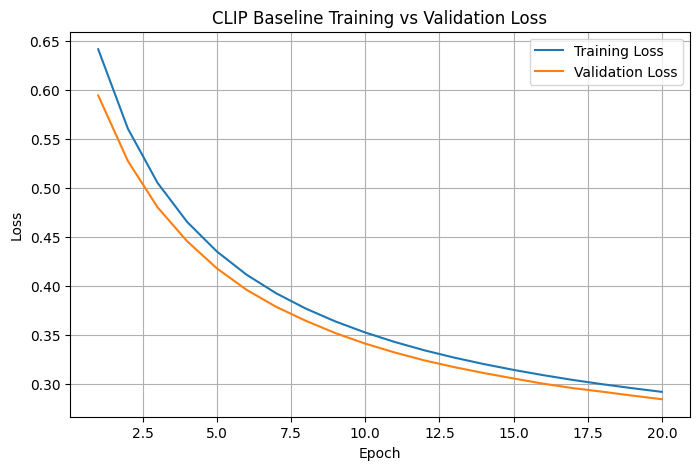

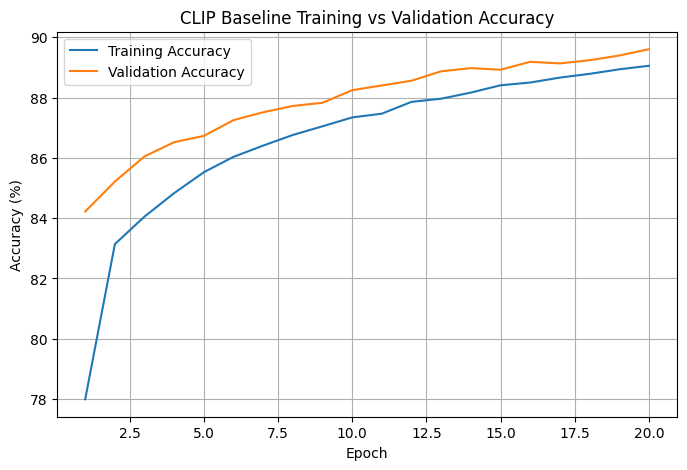

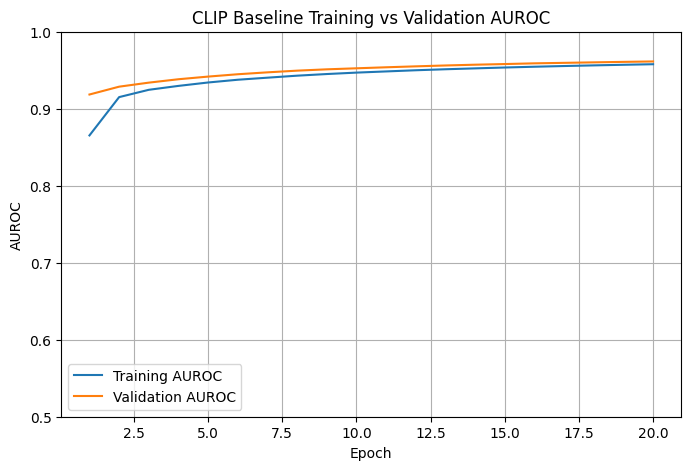

In [48]:
plot_history(clip_history, ap=False, model_name="CLIP Baseline")

In [49]:
test_results_clip = evaluate_model(
    model=model_clip,
    test_loader=clip_test_loader,
    device=device
)

======== Test Results ========
Test Loss: 0.2844
Test Accuracy: 89.60%
Test AUROC: 0.9614
Test AP: 0.9632
Real Accuracy: 89.66%
AI Accuracy: 89.55%


In [ ]:
print_test_result(test_results)
print_test_result(test_results_clip)

======== Test Results ========
Test Loss: 0.3443
Test Accuracy: 90.08%
Test AUROC: 0.9675
Test AP: 0.9658
Real Accuracy: 86.27%
AI Accuracy: 93.89%
======== Test Results ========
Test Loss: 0.2385
Test Accuracy: 91.12%
Test AUROC: 0.9715
Test AP: 0.9729
Real Accuracy: 90.89%
AI Accuracy: 91.35%


In [ ]:
best_epoch_clip = 20

# 3. NPR Baseline

In [50]:
npr_train_transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.RandomCrop(224),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

npr_val_transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.CenterCrop(224),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

npr_train_data = PairDataset(root_dir=train_dir, transform=npr_train_transform)
npr_val_data = PairDataset(root_dir=val_dir,transform=npr_val_transform)
npr_test_data = PairDataset(root_dir=test_dir, transform=npr_val_transform)

print("Training images:", len(npr_train_data))
print("Validation images:", len(npr_val_data))

Training images: 15302
Validation images: 1914


In [51]:
npr_train_loader, npr_val_loader, npr_test_loader = load_data(npr_train_data, npr_val_data, npr_test_data, 32, 4)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [52]:
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)

def conv1x1(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)

In [53]:
class Bottleneck(nn.Module):

    expansion = 4

    def __init__(self, in_channels, channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = conv1x1(in_channels, channels)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = conv3x3(channels, channels, stride)
        self.bn2 = nn.BatchNorm2d(channels)
        self.conv3 = conv1x1(channels,channels * self.expansion)
        self.bn3 = nn.BatchNorm2d(channels * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample


    def forward(self, x):

        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [54]:
class NPRDetector(nn.Module):

    def __init__(self):
        super().__init__()

        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(channels=64, blocks=3, stride=1)
        self.layer2 = self._make_layer(channels=128, blocks=4, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, 1)


        # =====================================
        # Weight initialization
        # =====================================

        for module in self.modules():

            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")

            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)

    def _make_layer(self, channels, blocks, stride=1):

        downsample = None

        output_channels = (channels * Bottleneck.expansion)


        # Need projection when dimensions change
        if (stride != 1 or self.in_channels != output_channels):

            downsample = nn.Sequential(
                conv1x1(self.in_channels, output_channels, stride),
                nn.BatchNorm2d(output_channels)
            )

        layers = []

        # First bottleneck
        layers.append(
            Bottleneck(self.in_channels, channels, stride, downsample)
        )
        self.in_channels = output_channels


        # Remaining bottlenecks
        for _ in range(1, blocks):
            layers.append(Bottleneck(self.in_channels,channels))

        return nn.Sequential(*layers)


    def get_npr(self, x):

        x_half = F.interpolate(x, scale_factor=0.5, mode="nearest", recompute_scale_factor=True)
        x_reconstructed = F.interpolate(x_half, scale_factor=2.0, mode="nearest", recompute_scale_factor=True)

        npr = (x - x_reconstructed)

        return npr


    def forward(self, x):

        npr = self.get_npr(x)

        x = self.conv1(npr * (2.0 / 3.0))
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        logits = self.classifier(x)

        return logits


In [55]:
def train_npr_model(model, train_loader, val_loader, epochs=50, learning_rate=2e-4, threshold=0.5):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10,gamma=0.9)

    history = {

        "train_loss": [],
        "train_acc": [],
        "train_auc": [],
        #Precision–recall performance across thresholds
        "train_ap": [],

        "val_loss": [],
        "val_acc": [],
        "val_auc": [],
        "val_ap": []
    }


    model = model.to(device)

    for epoch in range(epochs):

        model.train()

        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_probs = []
        train_labels = []


        for images, labels in train_loader:

            images = images.to(device)
            labels = (labels.float().to(device))

            optimizer.zero_grad()
            logits = model(images).squeeze(1)
            loss = criterion(logits,labels)
            loss.backward()
            optimizer.step()
            train_loss += (loss.item()* images.size(0))
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= threshold).float()


            # -----------------------------
            # Accuracy
            # -----------------------------

            train_correct += (predictions == labels).sum().item()


            train_total += (labels.size(0))
            train_probs.extend(probabilities.detach().cpu().numpy())
            train_labels.extend(labels.detach().cpu().numpy())


        train_loss /= (train_total)
        train_acc = (train_correct / train_total)
        train_auc = roc_auc_score(train_labels, train_probs)
        train_ap = average_precision_score(train_labels, train_probs)

        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0

        val_probs = []
        val_labels = []


        with torch.no_grad():

            for images, labels in val_loader:
                images = images.to(device)
                labels = (labels.float().to(device))

                logits = model(images).squeeze(1)

                loss = criterion(logits, labels)
                val_loss += (loss.item() * images.size(0))

                probabilities = torch.sigmoid(logits)
                predictions = (probabilities >= threshold).float()

                val_correct += (predictions == labels).sum().item()
                val_total += (labels.size(0))

                val_probs.extend(probabilities.cpu().numpy())


                val_labels.extend(

                    labels
                    .cpu()
                    .numpy()
                )

        val_loss /= (val_total)
        val_acc = (val_correct / val_total)
        val_auc = roc_auc_score(val_labels, val_probs)
        val_ap = average_precision_score(val_labels, val_probs)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_auc"].append(train_auc)
        history["train_ap"].append(train_ap)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)
        history["val_ap"].append(val_ap)


        print(

            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc*100:.2f}% | "
            f"Train AUC: {train_auc:.4f} | "
            f"Train AP: {train_ap:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc*100:.2f}% | "
            f"Val AUC: {val_auc:.4f} | "
            f"Val AP: {val_ap:.4f}"
        )

        scheduler.step()


    return model, history

In [56]:
local_time = datetime.now(tz)
print("Job starting on Singapore time:", local_time)
EPOCHS = 25
LEARNING_RATE = 2e-4

npr_model = NPRDetector()
npr_model, npr_history = train_npr_model(model=npr_model, train_loader=npr_train_loader, val_loader=npr_val_loader, epochs=EPOCHS,learning_rate=LEARNING_RATE)

local_time = datetime.now(tz)
print("Job end on Singapore time:", local_time)

Job starting on Singapore time: 2026-08-31 21:06:18.893187+08:00
Epoch [1/25] | Train Loss: 0.6367 | Train Acc: 63.66% | Train AUC: 0.6893 | Train AP: 0.6822 | Val Loss: 0.6031 | Val Acc: 67.14% | Val AUC: 0.7422 | Val AP: 0.7403
Epoch [2/25] | Train Loss: 0.5847 | Train Acc: 69.19% | Train AUC: 0.7592 | Train AP: 0.7532 | Val Loss: 0.5749 | Val Acc: 68.65% | Val AUC: 0.7822 | Val AP: 0.7839
Epoch [3/25] | Train Loss: 0.5586 | Train Acc: 71.30% | Train AUC: 0.7860 | Train AP: 0.7791 | Val Loss: 0.5280 | Val Acc: 74.71% | Val AUC: 0.8157 | Val AP: 0.8172
Epoch [4/25] | Train Loss: 0.5307 | Train Acc: 73.85% | Train AUC: 0.8117 | Train AP: 0.8077 | Val Loss: 0.5445 | Val Acc: 72.78% | Val AUC: 0.8203 | Val AP: 0.8224
Epoch [5/25] | Train Loss: 0.5153 | Train Acc: 74.88% | Train AUC: 0.8253 | Train AP: 0.8169 | Val Loss: 0.5459 | Val Acc: 72.52% | Val AUC: 0.8005 | Val AP: 0.8056
Epoch [6/25] | Train Loss: 0.4966 | Train Acc: 75.83% | Train AUC: 0.8390 | Train AP: 0.8359 | Val Loss: 0.524

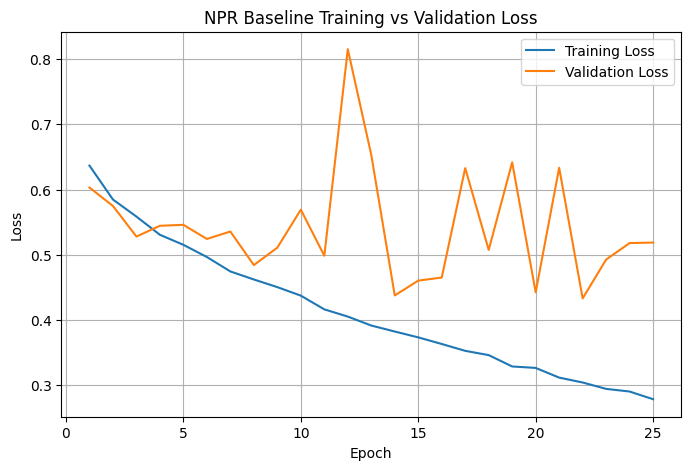

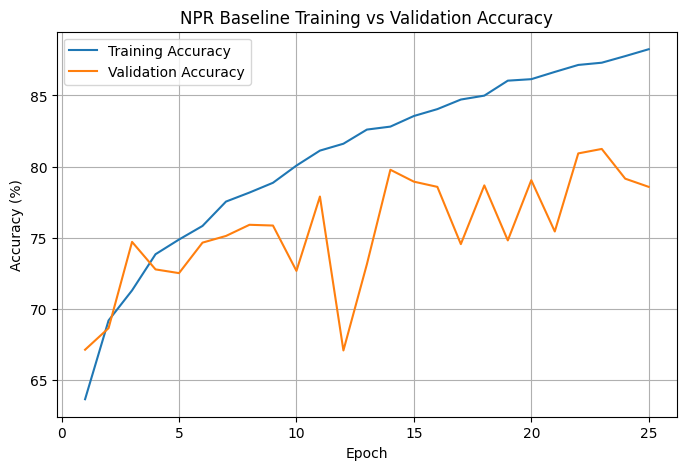

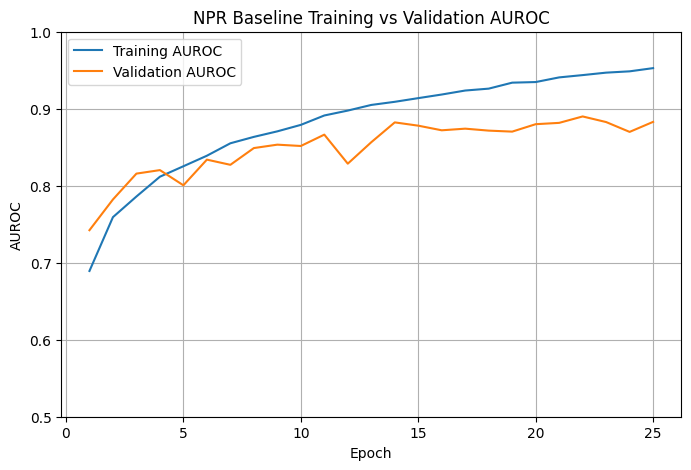

In [57]:
plot_history(npr_history, ap=False, model_name="NPR Baseline")

In [58]:
test_results_npr = evaluate_model(
    model=npr_model,
    test_loader=npr_test_loader,
    device=device
)

======== Test Results ========
Test Loss: 0.5035
Test Accuracy: 78.82%
Test AUROC: 0.8836
Test AP: 0.8850
Real Accuracy: 69.56%
AI Accuracy: 88.08%


In [ ]:
best_epoch_npr = 25

# 4.VIB Baseline

In [59]:
import open_clip

In [60]:
clip_backbone, _, clip_preprocess = (
    open_clip.create_model_and_transforms(
        "ViT-L-14",
        pretrained="openai"
    )
)

print("CLIP loaded")
print("Feature dimension:", clip_backbone.visual.output_dim)

# ============================================================
# 4. CREATE DATASETS
# ============================================================

vib_train_data = PairDataset(train_dir, transform=clip_preprocess)
vib_val_data = PairDataset(val_dir, transform=clip_preprocess)
vib_test_data = PairDataset(test_dir, transform=clip_preprocess)

print("Training images:", len(vib_train_data))
print("Validation images:", len(vib_val_data))
print("Test images:", len(vib_test_data))

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP loaded
Feature dimension: 768
Training images: 15302
Validation images: 1914
Test images: 1912


In [68]:
vib_train_loader, vib_val_loader, vib_test_loader = load_data_w_visual(vib_train_data, vib_val_data, vib_test_data, 32, 4)

Output hidden; open in https://colab.research.google.com to view.

In [62]:
class VIBDetector(nn.Module):

    def __init__(self,backbone, feature_dim=768, latent_dim=256, dropout=0.5, freeze_clip=False):
        super().__init__()

        self.backbone = backbone
        self.latent_dim = latent_dim
        self.freeze_clip = freeze_clip

        if freeze_clip:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(feature_dim,1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc_statistics = nn.Linear(1024, latent_dim * 2)
        self.classifier = nn.Linear(latent_dim, 1)


    def reparameterize(self,mu,std):
        epsilon = torch.randn_like(std)

        z = (mu + std * epsilon)
        return z

    def forward(self, images):

        features = self.backbone.encode_image(images)
        features = features.float()

        x = self.dropout(features)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)

        statistics = self.fc_statistics(x)

        mu = statistics[:,:self.latent_dim]
        raw_std = statistics[:,self.latent_dim:]
        std = F.softplus(raw_std - 5.0)

        z = self.reparameterize(mu, std)
        logits = self.classifier(z)

        return logits, mu, std

In [63]:
def kl_divergence(mu, std):
    variance = std.pow(2)
    kl = 0.5 * (mu.pow(2) + variance - torch.log(variance + 1e-8) - 1)

    return (kl.sum(dim=1).mean())

In [64]:
def train_vib_model(model, train_loader, val_loader, device, epochs=20, learning_rate=1e-4, beta=1e-4, threshold=0.5):


    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_cls_loss": [],
        "train_kl_loss": [],
        "train_acc": [],
        "train_auc": [],
        "train_ap": [],

        "val_loss": [],
        "val_cls_loss": [],
        "val_kl_loss": [],
        "val_acc": [],
        "val_auc": [],
        "val_ap": []
    }


    model = model.to(device)

    for epoch in range(epochs):
        model.train()

        if model.freeze_clip:
            model.backbone.eval()


        train_total_loss = 0.0
        train_cls_loss = 0.0
        train_kl_loss = 0.0
        train_correct = 0
        train_total = 0

        train_probs = []
        train_labels = []


        for images, labels in train_loader:
            images = images.to(device)
            labels = (labels.float().to(device))

            optimizer.zero_grad()

            logits, mu, std = model(images)
            logits = logits.squeeze(1)

            cls_loss = criterion(logits, labels)
            kl_loss = kl_divergence(mu, std)

            loss = (cls_loss + beta * kl_loss)
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)


            train_total_loss += (loss.item() * batch_size)
            train_cls_loss += (cls_loss.item() * batch_size)
            train_kl_loss += (kl_loss.item() * batch_size)

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= threshold).float()

            train_correct += (predictions == labels).sum().item()
            train_total += (labels.size(0))

            train_probs.extend(probabilities.detach().cpu().numpy())
            train_labels.extend(labels.detach().cpu().numpy())

        train_total_loss /= train_total
        train_cls_loss /= train_total
        train_kl_loss /= train_total

        train_acc = (train_correct / train_total)
        train_auc = roc_auc_score(train_labels, train_probs)
        train_ap = average_precision_score(train_labels, train_probs)

        model.eval()

        val_total_loss = 0.0
        val_cls_loss = 0.0
        val_kl_loss = 0.0
        val_correct = 0
        val_total = 0
        val_probs = []
        val_labels = []


        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = (labels.float().to(device))

                logits, mu, std = model(images)
                logits = logits.squeeze(1)

                cls_loss = criterion(logits, labels)
                kl_loss = kl_divergence(mu, std)
                loss = (cls_loss + beta * kl_loss)

                batch_size = images.size(0)
                val_total_loss += (loss.item() * batch_size)
                val_cls_loss += (cls_loss.item() * batch_size)
                val_kl_loss += (kl_loss.item() * batch_size)

                probabilities = torch.sigmoid(logits)
                predictions = (probabilities >= threshold).float()

                val_correct += (predictions == labels).sum().item()
                val_total += (labels.size(0))
                val_probs.extend(probabilities.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())


        val_total_loss /= val_total
        val_cls_loss /= val_total
        val_kl_loss /= val_total
        val_acc = (val_correct / val_total)
        val_auc = roc_auc_score(val_labels, val_probs)
        val_ap = average_precision_score(val_labels, val_probs)

        history["train_loss"].append(train_total_loss)
        history["train_cls_loss"].append(train_cls_loss)
        history["train_kl_loss"].append(train_kl_loss)
        history["train_acc"].append(train_acc)
        history["train_auc"].append(train_auc)
        history["train_ap"].append(train_ap)

        history["val_loss"].append(val_total_loss)
        history["val_cls_loss"].append(val_cls_loss)
        history["val_kl_loss"].append(val_kl_loss)
        history["val_acc"].append(val_acc)
        history["val_auc"].append(val_auc)
        history["val_ap"].append(val_ap)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "

            f"Train Loss: {train_total_loss:.4f} | "
            f"Train Acc: {train_acc*100:.2f}% | "
            f"Train AUC: {train_auc:.4f} | "
            f"Train AP: {train_ap:.4f} | "

            f"Val Loss: {val_total_loss:.4f} | "
            f"Val Acc: {val_acc*100:.2f}% | "
            f"Val AUC: {val_auc:.4f} | "
            f"Val AP: {val_ap:.4f} | "

            f"KL: {val_kl_loss:.4f}"
        )


    return model, history

In [ ]:
local_time = datetime.now(tz)
print("Job starting on Singapore time:", local_time)


EPOCHS = 10
LEARNING_RATE = 1e-4
BETA = 1e-4
vib_model = VIBDetector(backbone=clip_backbone, feature_dim=768, latent_dim=256, dropout=0.5,freeze_clip=True)
vib_model, vib_history = train_vib_model(model=vib_model, train_loader=vib_train_loader, val_loader=vib_val_loader, device=device, epochs=EPOCHS, learning_rate=LEARNING_RATE, beta=BETA)

local_time = datetime.now(tz)
print("Job ending on Singapore time:", local_time)


Job starting on Singapore time: 2026-08-31 22:00:10.520203+08:00
Epoch [1/10] | Train Loss: 0.4520 | Train Acc: 80.43% | Train AUC: 0.8886 | Train AP: 0.8907 | Val Loss: 0.3075 | Val Acc: 87.57% | Val AUC: 0.9597 | Val AP: 0.9591 | KL: 285.1088
Epoch [2/10] | Train Loss: 0.3654 | Train Acc: 84.24% | Train AUC: 0.9224 | Train AP: 0.9232 | Val Loss: 0.2760 | Val Acc: 90.75% | Val AUC: 0.9647 | Val AP: 0.9641 | KL: 311.1031
Epoch [3/10] | Train Loss: 0.3449 | Train Acc: 85.48% | Train AUC: 0.9309 | Train AP: 0.9326 | Val Loss: 0.2964 | Val Acc: 88.40% | Val AUC: 0.9676 | Val AP: 0.9665 | KL: 283.1199
Epoch [4/10] | Train Loss: 0.3333 | Train Acc: 86.07% | Train AUC: 0.9354 | Train AP: 0.9368 | Val Loss: 0.2722 | Val Acc: 90.23% | Val AUC: 0.9707 | Val AP: 0.9705 | KL: 315.0609
Epoch [5/10] | Train Loss: 0.3078 | Train Acc: 87.15% | Train AUC: 0.9452 | Train AP: 0.9465 | Val Loss: 0.2742 | Val Acc: 90.28% | Val AUC: 0.9730 | Val AP: 0.9724 | KL: 315.3265
Epoch [6/10] | Train Loss: 0.2912 |

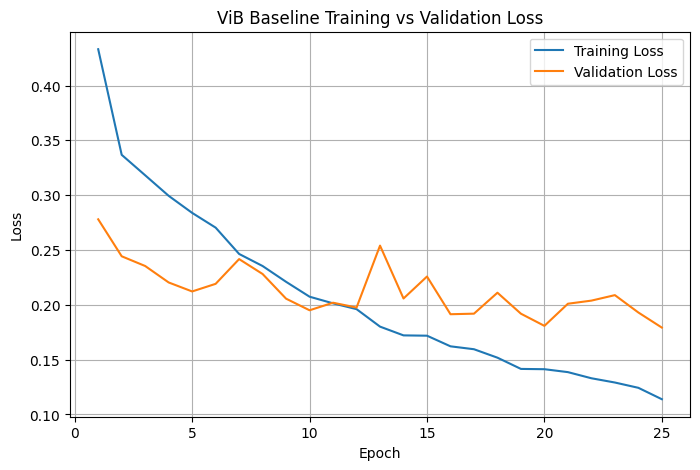

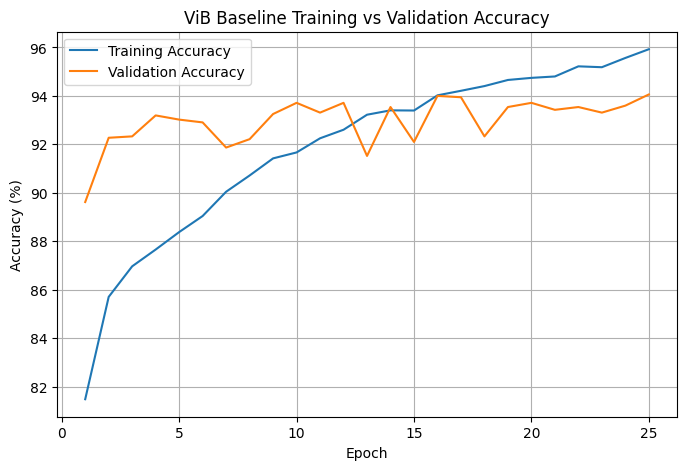

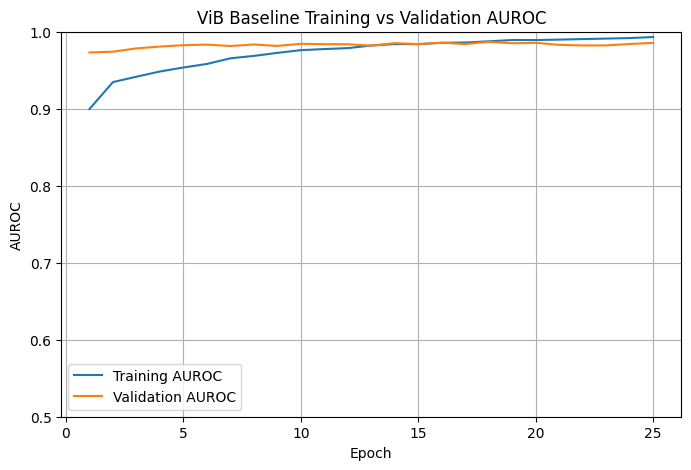

In [ ]:
plot_history(vib_history, ap=False, model_name="ViB Baseline")

In [ ]:
def evaluate_vib_model(model, test_loader, device):

    criterion = nn.BCEWithLogitsLoss()

    model.eval()

    test_loss = 0.0
    test_correct = 0
    test_total = 0

    test_probs = []
    test_labels = []


    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = (labels.float().to(device))

            logits, mu, std = model(images)
            logits = logits.squeeze(1)

            loss = criterion(logits, labels)
            test_loss += (loss.item() * images.size(0))

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()

            test_correct += (predictions == labels).sum().item()
            test_total += labels.size(0)
            test_probs.extend(probabilities.cpu().numpy())
            test_labels.extend(labels.cpu().numpy())


    test_loss = test_loss / test_total
    test_acc = test_correct / test_total

    test_auc = roc_auc_score(test_labels, test_probs)
    test_ap = average_precision_score(test_labels, test_probs)


    real_correct = 0
    real_total = 0

    ai_correct = 0
    ai_total = 0


    for label, probability in zip(test_labels, test_probs):

        prediction = 1 if probability >= 0.5 else 0

        if label == 0:
            real_total += 1
            if prediction == 0:
                real_correct += 1
        elif label == 1:
            ai_total += 1
            if prediction == 1:
                ai_correct += 1


    real_acc = real_correct / real_total if real_total > 0 else 0
    ai_acc = ai_correct / ai_total if ai_total > 0 else 0


    print("======== VIB Test Results ========")

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Test AUROC: {test_auc:.4f}")
    print(f"Test AP: {test_ap:.4f}")

    print(f"Real Accuracy: {real_acc * 100:.2f}%")
    print(f"AI Accuracy: {ai_acc * 100:.2f}%")


    return {
        "loss": test_loss,
        "accuracy": test_acc,
        "auroc": test_auc,
        "ap": test_ap,
        "real_accuracy": real_acc,
        "ai_accuracy": ai_acc
    }

In [ ]:
test_results_vib = evaluate_vib_model(
    model=vib_model,
    test_loader=vib_test_loader,
    device=device
)

======== VIB Test Results ========
Test Loss: 0.1650
Test Accuracy: 93.31%
Test AUROC: 0.9840
Test AP: 0.9835
Real Accuracy: 92.96%
AI Accuracy: 93.66%


In [ ]:
print_test_result(test_results)

In [ ]:
best_epoch_vib=10

# Storing model data

In [ ]:
print_test_result(test_results)

print_test_result(test_results_clip)
print_test_result(test_results_npr)
print_test_result(test_results_vib)


In [ ]:
save_path = "/content/drive/MyDrive/baselines_original/saved_model/resnet_18"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": "ResNet18",
    "threshold": 0.5,
    "best_epoch": best_epoch,
    "best_val_auc": best_val_auc
}

torch.save(
    checkpoint,
    save_path
)

In [ ]:
save_path = "/content/drive/MyDrive/baselines_original/saved_model/Clip"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": "ResNet18",
    "threshold": 0.5,
    "best_epoch": best_epoch_clip,
    "best_val_auc": best_val_auc
}

torch.save(
    checkpoint,
    save_path
)

In [ ]:
save_path = "/content/drive/MyDrive/baselines_original/saved_model/Npr"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": "ResNet18",
    "threshold": 0.5,
    "best_epoch": best_epoch_npr,
    "best_val_auc": best_val_auc
}

torch.save(
    checkpoint,
    save_path
)

In [ ]:
save_path = "/content/drive/MyDrive/baselines_original/saved_model/ViB"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_name": "ResNet18",
    "threshold": 0.5,
    "best_epoch": best_epoch_vib,
    "best_val_auc": best_val_auc
}

torch.save(
    checkpoint,
    save_path
)

In [ ]:
# # inference
# checkpoint = torch.load(
#     "/content/drive/MyDrive/models/resnet18_best.pth",
#     map_location=device
# )

# model = ResNetBaseline(
#     dropout=0.3
# )

# model.load_state_dict(
#     checkpoint["model_state_dict"]
# )

# model = model.to(device)
# model.eval()